In [ ]:
#  https://www.kaggle.com/datasets/gpiosenka/sports-classification?resource=download
import kagglehub
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Set up the paths to your dataset directories
train_dir = './dataset/train'
test_dir = './dataset/test'

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), class_mode='categorical', batch_size=32)
test_data = test_datagen.flow_from_directory(test_dir, target_size=(224, 224), class_mode='categorical', batch_size=32)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_cnn_from_scratch():
    model = Sequential([
        Input(shape=(224, 224, 3)),  
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(7, activation='softmax') 
    ])
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model
cnn_from_scratch = create_cnn_from_scratch()
history_scratch = cnn_from_scratch.fit(train_data, epochs=10)


In [8]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

def create_transfer_learning_model():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(7, activation='softmax')(x)  

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

transfer_learning_model = create_transfer_learning_model()
history_transfer_learning = transfer_learning_model.fit(train_data, epochs=10)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 243s 7s/step - accuracy: 0.2115 - loss: 2.0025
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 859s 27s/step - accuracy: 0.3841 - loss: 1.6195
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 244s 8s/step - accuracy: 0.4663 - loss: 1.4525
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 239s 7s/step - accuracy: 0.5652 - loss: 1.2856
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 241s 8s/step - accuracy: 0.5879 - loss: 1.1984
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 240s 7s/step - accuracy: 0.6795 - loss: 1.0565
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 241s 7s/step - accuracy: 0.6769 - loss: 0.9642
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 261s 7s/step - accuracy: 0.7096 - loss: 0.9250
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 240s 7s/step - accuracy: 0.7477 - loss: 0.8387
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 237s 7s/step - accuracy: 0.7400 - loss: 0.8049


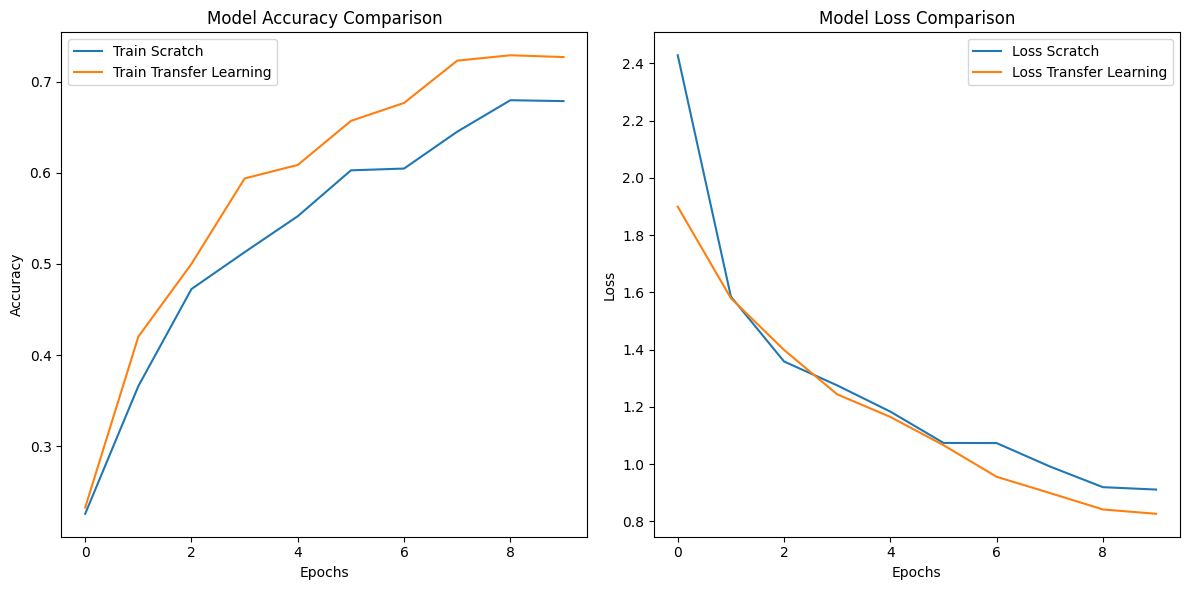

In [9]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_scratch.history['accuracy'], label='Train Scratch')
plt.plot(history_transfer_learning.history['accuracy'], label='Train Transfer Learning')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_scratch.history['loss'], label='Loss Scratch')
plt.plot(history_transfer_learning.history['loss'], label='Loss Transfer Learning')
plt.title('Model Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
test_loss_scratch, test_accuracy_scratch = cnn_from_scratch.evaluate(test_data)
test_loss_transfer, test_accuracy_transfer = transfer_learning_model.evaluate(test_data)

print(f"Accuracy (Scratch): {test_accuracy_scratch:.4f}")
print(f"Accuracy (Transfer Learning): {test_accuracy_transfer:.4f}")

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8042 - loss: 0.6401
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 789ms/step - accuracy: 0.9116 - loss: 0.5259
Accuracy (Scratch): 0.8000
Accuracy (Transfer Learning): 0.9143
